# Simulating Juliette

In [1]:
import pandas as pd
import xarray as xr
import numpy as np
from opendrift.models.openberg import OpenBerg
from opendrift.readers.reader_netCDF_CF_generic import Reader    
from datetime import datetime,timedelta, timezone
from utils2 import calc_iceberg_size

SyntaxError: invalid syntax (utils2.py, line 1)

In [ ]:
input_l = ['cmems_obs-wind_glo_phy_nrt_l4_0.125deg_PT1H',
           'cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H'

In [258]:
def calc_iceberg_size(iceberg_in1):
    '''Correct iceberg size not supplied with empirical relations before seeding iceberg.
    '''
    lengths = iceberg_in1['length']
    if 'length' in iceberg_in1 and 'width' not in iceberg_in1:
        iceberg_in1['width'] = 0.7*lengths*np.exp(-0.00062*length)
    if 'length' in iceberg_in1 and np.logical_or('draft' not in iceberg_in1,'sail' not in iceberg_in1):
        rho_i, rho_w = 900,1027 #kg/m3
        height = np.array(0.3*lengths*np.exp(-0.00062*lengths))
        if np.logical_and('draft' not in iceberg_in1, 'sail' in iceberg_in1): print('Implement')
        elif np.logical_and('draft' not in iceberg_in1, 'sail' not in iceberg_in1): draft = height*(rho_i/rho_w)
        if np.logical_and('sail' not in iceberg_in1, 'draft' not in iceberg_in1): sail = height*(1-rho_i/rho_w) 
        elif np.logical_and('sail' not in iceberg_in1, 'draft' in iceberg_in1): print('Implement')
        iceberg_in1['draft'] = draft
        iceberg_in1['sail'] = sail
    return iceberg_in1

In [8]:
#Read and subset Tracker data
df = pd.read_csv('../input/Osker-X2.csv', sep=';')
df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
ds = xr.Dataset.from_dataframe(df)
ds_daily = ds.groupby("time.date").first()
ds_3day = ds_daily.isel(date=slice(0, None, 3))
#idx = np.arange(ds_3day.lat.size) #ADAPT LATER
idx=np.array([0,1,2])
print(idx)

[0 1 2]


In [ ]:
#OLD VERSION 
#def initial conditions
idxx=0
iceberg = {
            #'lat':None,'lon':None,'time':None,
           'length':200,'width':85, 
            'number':int(2*4),'radius':500}
iceberg = calc_iceberg_size(iceberg)

o=OpenBerg(loglevel=10,logfile='../results/out.log')
o.add_readers_from_list(['cmems_mod_glo_phy_anfc_0.083deg_PT1H-m','cmems_mod_arc_phy_my_topaz4_P1D-m',]) 
r = Reader('../input/era5_juliette.nc',standard_name_mapping={'u10':'x_wind','v10':'y_wind'},name='ERA5-Reader')
o.add_reader(r)
#o.seed_elements(**iceberg)
for idxx in idx: 
    o.seed_elements(lon=ds_3day.lon[idxx],lat=ds_3day.lat[idxx],time=ds_3day.time[idxx].astype("datetime64"),**iceberg)
    print(idxx,ds_3day.time[idxx])
oi = o.run(duration=timedelta(days=3),outfile='../results/out.nc')

oi

In [11]:
#TEST
i=0
dimensions = {'length': 200, 'width': 85, 'draft': 10, 'sail': 1}
o=OpenBerg(loglevel=10,logfile='../results/simulations_ts%s.log'%i)
o.add_readers_from_list(['cmems_mod_glo_phy_anfc_0.083deg_PT1H-m','cmems_mod_arc_phy_my_topaz4_P1D-m',]) 
r = Reader('../input/era5_juliette.nc',standard_name_mapping={'u10':'x_wind','v10':'y_wind'},name='ERA5-Reader')
o.add_reader(r)
for lon, lat, time in zip(ds_3day.lon[:3], ds_3day.lat[:3], ds_3day.time[:3]):
    o.seed_elements(lon=lon, lat=lat, time=time, number=100, radius=100, **dimensions)
#o.plot()
oi = o.run(duration=timedelta(days=3),outfile='../results/simulations_ts%s.nc'%i)
oi

Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00,  2.16it/s]
INFO - 2026-05-08T11:09:29Z - Selected dataset version: "202406"
INFO - 2026-05-08T11:09:29Z - Selected dataset part: "default"
Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00, 21.54it/s]
INFO - 2026-05-08T11:09:30Z - Selected dataset version: "202506"
INFO - 2026-05-08T11:09:30Z - Selected dataset part: "default"


<xarray.Dataset> Size: 1MB
Dimensions:                                   (trajectory: 100, time: 73)
Coordinates:
  * trajectory                                (trajectory) int32 400B 0 1 ... 99
  * time                                      (time) datetime64[ns] 584B 2025...
Data variables: (12/39)
    status                                    (trajectory, time) float64 58kB ...
    moving                                    (trajectory, time) float64 58kB ...
    age_seconds                               (trajectory, time) float32 29kB ...
    origin_marker                             (trajectory, time) float64 58kB ...
    lon                                       (trajectory, time) float32 29kB ...
    lat                                       (trajectory, time) float32 29kB ...
    ...                                        ...
    sea_water_salinity                        (trajectory, time) float32 29kB ...
    sea_ice_area_fraction                     (trajectory, time) float32 29kB ...
    sea_ice_thickness                         (trajectory, time) float32 29kB ...
    sea_ice_x_velocity                        (trajectory, time) float32 29kB ...
    sea_ice_y_velocity                        (trajectory, time) float32 29kB ...
    land_binary_mask                          (trajectory, time) float32 29kB ...
Attributes: (12/147)
    Conventions:                                                           CF...
    standard_name_vocabulary:                                              CF...
    featureType:                                                           tr...
    title:                                                                 Op...
    summary:                                                               Ou...
    keywords:                                                              tr...
    ...                                                                    ...
    geospatial_lon_units:                                                  de...
    geospatial_lon_resolution:                                             point
    runtime:                                                               0:...
    geospatial_vertical_min:                                               0.0
    geospatial_vertical_max:                                               0.0
    geospatial_vertical_positive:                                          up

In [17]:
oi.lat[:,0].values

array([75.00759 , 75.0047  , 75.00477 , 75.006775, 75.00485 , 75.007645,
       75.00554 , 75.00523 , 75.00763 , 75.00723 , 75.00758 , 75.00672 ,
       75.005135, 75.00762 , 75.00567 , 75.00662 , 75.00675 , 75.00577 ,
       75.006454, 75.00674 , 75.00624 , 75.00492 , 75.00617 , 75.007095,
       75.00529 , 75.005775, 75.005516, 75.00756 , 75.00651 , 75.00627 ,
       75.00522 , 75.00639 , 75.0053  , 75.005936, 75.00534 , 75.006516,
       75.006424, 75.00572 , 75.00626 , 75.00493 , 75.00457 , 75.0063  ,
       75.00606 , 75.00648 , 75.00804 , 75.00675 , 75.00509 , 75.006905,
       75.00473 , 75.00549 , 75.005844, 75.00744 , 75.00524 , 75.005165,
       75.00582 , 75.00531 , 75.00692 , 75.00494 , 75.004875, 75.005516,
       75.00546 , 75.00764 , 75.00676 , 75.00599 , 75.00481 , 75.00666 ,
       75.00501 , 75.004524, 75.00697 , 75.00619 , 75.00673 , 75.006195,
       75.006676, 75.005325, 75.00498 , 75.006516, 75.00519 , 75.00529 ,
       75.0055  , 75.00592 , 75.00559 , 75.00468 , 

In [ ]:
from datetime import datetime, timedelta
from opendrift.models.openberg import OpenBerg

lats = [75.005907, 75.071053, 75.088531, 75.164966, 75.156922, 75.14313 ,75.451136, 75.982464, 75.945248, 75.901178]
lons = [-58.177344, -58.29607 , -58.323546, -58.532602, -58.551392,-58.599142, -59.616499, -61.725523, -64.170816, -68.677523]
times = [datetime.now() + timedelta(days=i) for i in range(len(lons))]
dimensions = {'length': 200, 'width': 85, 'draft': 10, 'sail': 1}

o=OpenBerg(loglevel=50)
o.add_readers_from_list(['cmems_mod_glo_phy_anfc_0.083deg_PT1H-m',])

for lon, lat, time in zip(lons, lats, times):
    o.seed_elements(lon=lon, lat=lat, time=time, number=100, radius=100, **dimensions)
o.plot()

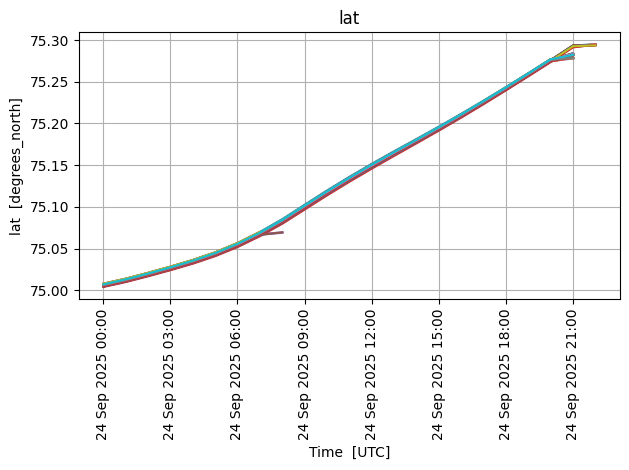

In [13]:
o.plot_property('lat')

AttributeError: 'numpy.datetime64' object has no attribute 'strftime'

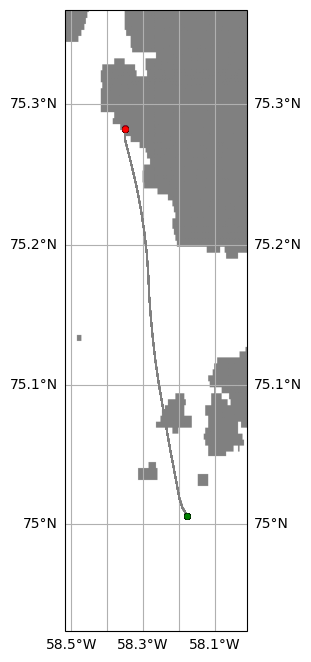

In [316]:
o.plot(fast=True)

In [3]:
o


Model:	OpenBerg     (OpenDrift version 1.14.9)
	0 active IcebergObj particles  (0 deactivated, 1000 scheduled)
-------------------
Environment variables:
  -----
  land_binary_mask
     1) global_landmask
  -----
Readers not added for the following variables:
  horizontal_diffusivity
  sea_floor_depth_below_sea_level
  sea_ice_area_fraction
  sea_ice_thickness
  sea_ice_x_velocity
  sea_ice_y_velocity
  sea_surface_height
  sea_surface_wave_from_direction
  sea_surface_wave_significant_height
  sea_surface_wave_stokes_drift_x_velocity
  sea_surface_wave_stokes_drift_y_velocity
  sea_surface_x_slope
  sea_surface_y_slope
  sea_water_salinity
  sea_water_temperature
  x_sea_water_velocity
  x_wind
  y_sea_water_velocity
  y_wind
---
Lazy readers:
  LazyReader: cmems_mod_glo_phy_anfc_0.083deg_PT1H-m

Discarded readers:

Tests to describe problem

In [233]:
#clean version 1 
iceberg = {'lat':np.array([75.005907, 75.071053, 75.088531]),'lon':np.array([-58.177344, -58.29607 , -58.323546]),
           'time':np.array(['2025-09-24T00:00:31.000000', '2025-09-27T00:00:31.000000','2025-09-30T00:00:31.000000'], dtype='datetime64[us]'),
           'length':200,'width':85, 'draft':10,'sail':1,
            'number':12}

o=OpenBerg(loglevel=20)
o.add_readers_from_list(['cmems_mod_glo_phy_anfc_0.083deg_PT1H-m',]) 
o.seed_elements(**iceberg)
oi = o.run(duration=timedelta(days=3))

oi

08:53:31 INFO    opendrift:568: OpenDriftSimulation initialised (version 1.14.9)
08:53:31 INFO    opendrift.models.basemodel.environment:203: Adding a global landmask from GSHHG
08:53:31 INFO    opendrift.models.basemodel.environment:227: Fallback values will be used for the following variables which have no readers: 
08:53:31 INFO    opendrift.models.basemodel.environment:230: 	x_sea_water_velocity: 0.000000
08:53:31 INFO    opendrift.models.basemodel.environment:230: 	y_sea_water_velocity: 0.000000
08:53:31 INFO    opendrift.models.basemodel.environment:230: 	sea_floor_depth_below_sea_level: 10000.000000
08:53:31 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_height: 0.000000
08:53:31 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_x_slope: 0.000000
08:53:31 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_y_slope: 0.000000
08:53:31 INFO    opendrift.models.basemodel.environment:230: 	x_wind: 0.000000
08:53:31 INFO    opendrift.model

ValueError: Time array has length 3, must be 1, 2 or 12

In [ ]:
#clean version 2
iceberg = {'lat':75.005907,'lon':-58.177344,
           'time':[datetime(2025,9,24),datetime(2025,9,27)],
           'length':200,'width':85, 'draft':10,'sail':1,
            'number':10,'radius':0}

o=OpenBerg(loglevel=50)
o.add_readers_from_list(['cmems_mod_glo_phy_anfc_0.083deg_PT1H-m',]) 
o.seed_elements(**iceberg)
oi = o.run(duration=timedelta(days=3))

oi

#N=100,trajectory=100, from 100 time steps between the given ones
#n=2, trajectory=1!

In [248]:
#clean version 3
iceberg = {'lat':[75.005907, 75.071053, 75.088531, 75.164966, 75.156922, 75.14313 ,75.451136, 75.982464, 75.945248, 75.901178],
                  'lon':[-58.177344, -58.29607 , -58.323546, -58.532602, -58.551392,-58.599142, -59.616499, -61.725523, -64.170816, -68.677523],
           'time':[t.values.astype(datetime) for t in ds_3day.time[:10]],
           'length':200,'width':85, 'draft':10,'sail':1,
            'number':20,'radius':0}

o=OpenBerg(loglevel=50)
o.add_readers_from_list(['cmems_mod_glo_phy_anfc_0.083deg_PT1H-m',]) 
o.seed_elements(**iceberg)
oi = o.run(duration=timedelta(days=3))

oi

#N=100,trajectory=100, from 100 time steps between the given ones, frist half of time first lat, and so on
#n=2, trajectory=1!

ValueError: Time array has length 10, must be 1, 2 or 20

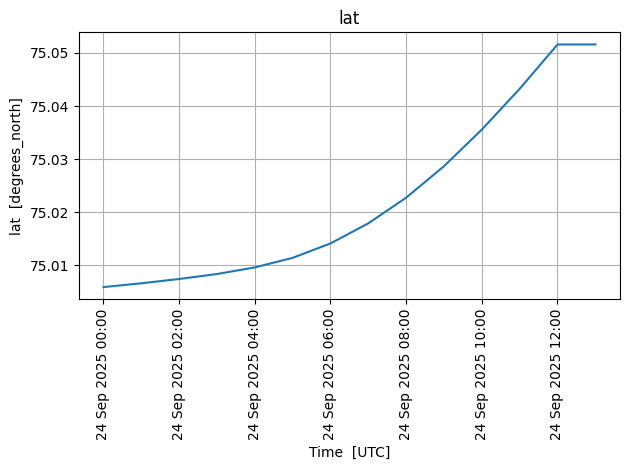

In [246]:
o.plot_property('lat')

In [ ]:
#test 2-3 sizes, by sat L=200m, W=85, D%??

#coeffcients: 
